In [1]:
import sys
sys.path.append("/Users/hnq/Desktop/licenta/cod_plante")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import numpy as np
import time
from pathlib import Path
from src.data_loaders import get_dataloaders, get_class_names, get_device

train_loader, val_loader = get_dataloaders()
class_names = get_class_names()
device = get_device()

print(f"Device: {device}")
print(f"Number of classes: {len(class_names)}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Device: mps
Number of classes: 38
Train batches: 1358
Val batches: 340


In [2]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=38):
        super().__init__()
        
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        self.conv4 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        
        self.relu = nn.ReLU(inplace=True)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(256 * 14 * 14, 512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)
        
    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        x = self.pool(self.relu(self.bn4(self.conv4(x))))
        
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

model = CustomCNN(num_classes=38)
print(model)

CustomCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=50176, out_features=512, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=38, bias

In [3]:
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model is on device: {next(model.parameters()).device}")

Total parameters: 26,099,494
Trainable parameters: 26,099,494
Model is on device: mps:0


In [4]:
images, labels = next(iter(train_loader))
images = images.to(device)

with torch.no_grad():
    output = model(images)

print(f"Input shape:  {images.shape}")
print(f"Output shape: {output.shape}")

Input shape:  torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 38])


In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3,
)

print(f"Loss function: {criterion}")
print(f"Optimizer: Adam with lr=1e-3")
print(f"Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)")

Loss function: CrossEntropyLoss()
Optimizer: Adam with lr=1e-3
Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)


In [6]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(loader, desc="Training", leave=False):
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    avg_loss = running_loss / total
    accuracy = 100.0 * correct / total
    
    return avg_loss, accuracy

In [7]:
def validate_epoch(model, loader, criterion, device):
    model.eval()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation", leave=False):
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    avg_loss = running_loss / total
    accuracy = 100.0 * correct / total
    
    return avg_loss, accuracy

In [8]:
NUM_EPOCHS = 30

MODEL_PATH = Path("/Users/hnq/Desktop/licenta/cod_plante/models")
MODEL_PATH.mkdir(exist_ok=True)
BEST_MODEL_FILE = MODEL_PATH / "n03_cnn_custom_scratch.pth"

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

best_val_acc = 0.0

start_time = time.time()

print(f"Starting training for {NUM_EPOCHS} epochs...")
print(f"Model will be saved to: {BEST_MODEL_FILE}\n")

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    
    scheduler.step(val_loss)
    
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    
    current_lr = optimizer.param_groups[0]['lr']
    
    epoch_time = time.time() - epoch_start
    
    print(f"Epoch {epoch:2d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}% | "
          f"LR: {current_lr:.6f} | "
          f"Time: {epoch_time:.1f}s")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), BEST_MODEL_FILE)
        print(f"   -> New best model saved (val_acc: {best_val_acc:.2f}%)")

total_time = time.time() - start_time
print(f"\nTraining completed in {total_time/60:.1f} minutes")
print(f"Best validation accuracy: {best_val_acc:.2f}%")
print(f"Best model saved at: {BEST_MODEL_FILE}")

Starting training for 30 epochs...
Model will be saved to: /Users/hnq/Desktop/licenta/cod_plante/models/n03_cnn_custom_scratch.pth



Training:   0%|          | 0/1358 [00:00<?, ?it/s]

Validation:   0%|          | 0/340 [00:00<?, ?it/s]

Epoch  1/30 | Train Loss: 3.3071 Acc: 18.08% | Val Loss: 2.4900 Acc: 28.55% | LR: 0.001000 | Time: 291.3s
   -> New best model saved (val_acc: 28.55%)


Training:   0%|          | 0/1358 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/340 [00:00<?, ?it/s]

Epoch 29/30 | Train Loss: 0.6595 Acc: 79.00% | Val Loss: 0.2075 Acc: 94.01% | LR: 0.001000 | Time: 279.3s
   -> New best model saved (val_acc: 94.01%)


Training:   0%|          | 0/1358 [00:00<?, ?it/s]

Validation:   0%|          | 0/340 [00:00<?, ?it/s]

Epoch 30/30 | Train Loss: 0.6240 Acc: 80.07% | Val Loss: 0.1966 Acc: 94.16% | LR: 0.001000 | Time: 288.5s
   -> New best model saved (val_acc: 94.16%)

Training completed in 142.2 minutes
Best validation accuracy: 94.16%
Best model saved at: /Users/hnq/Desktop/licenta/cod_plante/models/n03_cnn_custom_scratch.pth


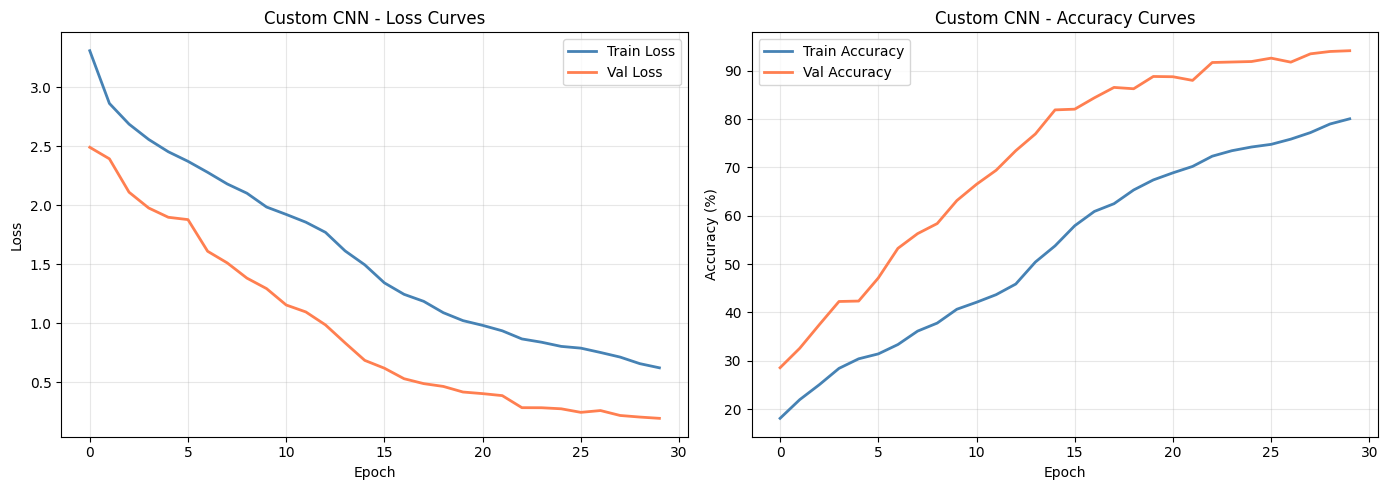

Final Train Loss: 0.6240
Final Val Loss: 0.1966
Final Train Acc: 80.07%
Final Val Acc: 94.16%
Best Val Acc: 94.16%


In [9]:
# Plot loss and accuracy curves for the CNN custom training
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Train Loss', linewidth=2, color='steelblue')
axes[0].plot(val_losses, label='Val Loss', linewidth=2, color='coral')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Custom CNN - Loss Curves')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_accuracies, label='Train Accuracy', linewidth=2, color='steelblue')
axes[1].plot(val_accuracies, label='Val Accuracy', linewidth=2, color='coral')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Custom CNN - Accuracy Curves')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('n03_loss_curves_cnn.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"Final Train Loss: {train_losses[-1]:.4f}")
print(f"Final Val Loss: {val_losses[-1]:.4f}")
print(f"Final Train Acc: {train_accuracies[-1]:.2f}%")
print(f"Final Val Acc: {val_accuracies[-1]:.2f}%")
print(f"Best Val Acc: {best_val_acc:.2f}%")